# **Практическая работа №10. Работа с растровыми данными в Rasterio**

---

**Данные для обработки:**

- Одноканальное изображение (ЦМР): https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
- Мультиспектральное изображение (Landsat): https://github.com/opengeos/datasets/releases/download/raster/cog.tif

### **Задание 1. Чтение и исследование растровых данных**



1. Откройте одноканальное изображение ЦМР с использованием `rasterio`.


In [47]:
import rasterio


def open_dem_raster(path: str) -> rasterio.io.DatasetReader:
    """
    Open DEM raster file using rasterio.

    :param path: Path to DEM GeoTIFF file

    :return: Rasterio dataset object
    """
    dataset = rasterio.open(path)
    return dataset


dem_path = (
    "https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif"
)

dem_dataset = open_dem_raster(dem_path)

dem_dataset

<open DatasetReader name='https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif' mode='r'>

2. Извлеките и выведите метаданные растра, включая СК, разрешение, границы, количество каналов и типы данных.


In [48]:
def print_raster_metadata(dataset: rasterio.io.DatasetReader) -> None:
    """
    Print raster metadata.

    :param dataset: Opened raster dataset
    """
    print("Система координат (CRS):", dataset.crs)
    print("Разрешение (размер пикселя):", dataset.res)
    print("Границы растра:", dataset.bounds)
    print("Количество каналов:", dataset.count)
    print("Тип данных пикселей:", dataset.dtypes)


print_raster_metadata(dem_dataset)

Система координат (CRS): EPSG:3857
Разрешение (размер пикселя): (90.0, 89.99579177642138)
Границы растра: BoundingBox(left=-13442488.3428, bottom=4388214.6777, right=-13058278.3428, top=4668371.5775)
Количество каналов: 1
Тип данных пикселей: ('int16',)


3. Отобразите ширину и высоту растра, а также типы данных пикселей, чтобы понять размеры сетки и структуру данных.

In [49]:
def print_raster_shape_and_dtype(
    dataset: rasterio.io.DatasetReader
) -> None:
    """
    Print raster width, height, and pixel data types.

    :param dataset: Opened raster dataset
    """
    print("Ширина растра (пиксели):", dataset.width)
    print("Высота растра (пиксели):", dataset.height)
    print("Тип данных пикселей:", dataset.dtypes)


print_raster_shape_and_dtype(dem_dataset)


Ширина растра (пиксели): 4269
Высота растра (пиксели): 3113
Тип данных пикселей: ('int16',)


---



### **Задание 2. Визуализация и манипулирование растровыми каналами**



1. Визуализируйте одноканальное изображение ЦМР с использованием пользовательской цветовой карты (например, cmap='terrain').


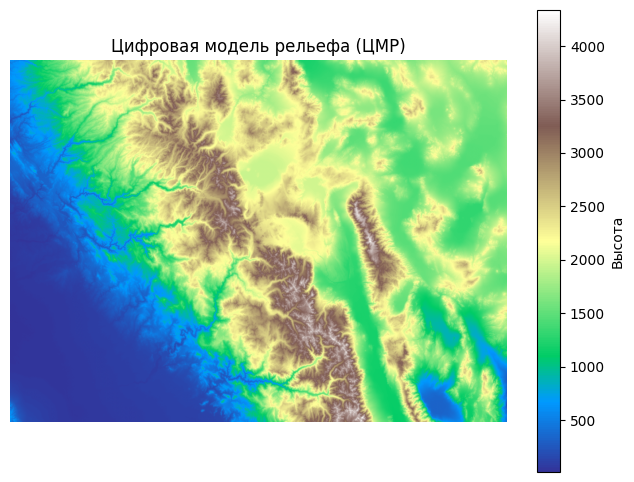

In [50]:
import matplotlib.pyplot as plt


def visualize_dem(dataset: rasterio.io.DatasetReader) -> None:
    """
    Visualize DEM raster using terrain colormap.

    :param dataset: Opened DEM raster dataset
    """
    dem_band = dataset.read(1)

    plt.figure(figsize=(8, 6))
    plt.imshow(dem_band, cmap="terrain")
    plt.colorbar(label="Высота")
    plt.title("Цифровая модель рельефа (ЦМР)")
    plt.axis("off")
    plt.show()


visualize_dem(dem_dataset)


2. Откройте мультиспектральное изображение и визуализируйте первый канал с использованием подходящей цветовой карты.


Количество каналов в растре: 4
Тип данных пикселей: ('float64', 'float64', 'float64', 'float64')


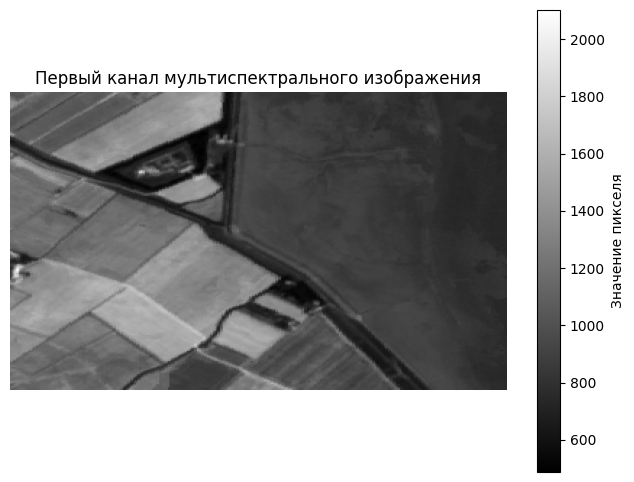

In [51]:
def visualize_first_band(path: str) -> None:
    """
    Open multispectral raster and visualize first band.

    :param path: Path to multispectral GeoTIFF file

    :return: None
    """
    with rasterio.open(path) as dataset:
        first_band = dataset.read(1)

        print("Количество каналов в растре:", dataset.count)
        print("Тип данных пикселей:", dataset.dtypes)

        plt.figure(figsize=(8, 6))
        plt.imshow(first_band, cmap="gray")
        plt.colorbar(label="Значение пикселя")
        plt.title("Первый канал мультиспектрального изображения")
        plt.axis("off")
        plt.show()


landsat_path = "https://github.com/opengeos/datasets/releases/download/raster/cog.tif"
visualize_first_band(landsat_path)

3. Объедините несколько каналов из мультиспектрального изображения (например, Красный, Зеленый и Синий) и совместите их в один массив для создания RGB-композитного изображения.

Каналы объединяются в порядке: Red, Green, Blue
Форма одного канала: (206, 343)


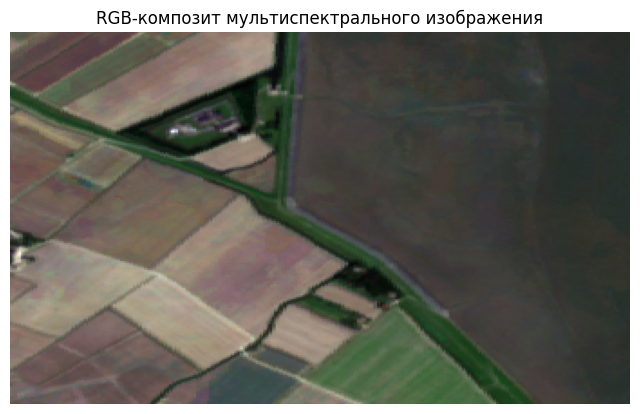

In [52]:
import numpy as np


def normalize_band(band: np.ndarray) -> np.ndarray:
    """
    Normalize raster band to range 0-1.

    :param band: Raster band array

    :return: Normalized band
    """
    band_min = band.min()
    band_max = band.max()

    return (band - band_min) / (band_max - band_min)


def visualize_rgb_composite(path: str) -> None:
    """
    Create and visualize RGB composite from multispectral raster.

    :param path: Path to multispectral GeoTIFF file

    :return: None
    """
    with rasterio.open(path) as dataset:
        red_band = dataset.read(1)
        green_band = dataset.read(2)
        blue_band = dataset.read(3)

        print("Каналы объединяются в порядке: Red, Green, Blue")
        print("Форма одного канала:", red_band.shape)

        red_norm = normalize_band(red_band)
        green_norm = normalize_band(green_band)
        blue_norm = normalize_band(blue_band)

        rgb_image = np.dstack((red_norm, green_norm, blue_norm))

        plt.figure(figsize=(8, 6))
        plt.imshow(rgb_image)
        plt.title("RGB-композит мультиспектрального изображения")
        plt.axis("off")
        plt.show()


visualize_rgb_composite(landsat_path)


---



### **Задание 3. Обрезка растра с использованием индексации массива**



1. Откройте мультиспектральное изображение и обрежьте его с использованием спискового среза (указав диапазоны строк и столбцов).


In [53]:
def crop_raster_by_index(
    path: str,
    row_start: int,
    row_size: int,
    col_start: int,
    col_size: int
) -> np.ndarray:
    """
    Crop multispectral raster using array slicing.

    :param path: Path to multispectral GeoTIFF file
    :param row_start: Start row index
    :param row_size: Number rows to crop
    :param col_start: Start column index
    :param col_size: Number columns to crop

    :return: Cropped raster array
    """
    with rasterio.open(path) as dataset:
        raster_data = dataset.read()

    rows_end = row_start + row_size
    cols_end = col_start + col_size

    cropped_data = raster_data[
        :,
        row_start:rows_end,
        col_start:cols_end
    ]

    print("Форма исходного массива:", raster_data.shape)
    print("Форма обрезанного массива:", cropped_data.shape)

    return cropped_data

cropped_raster = crop_raster_by_index(
    path=landsat_path,
    row_start=50,
    row_size=100,
    col_start=50,
    col_size=150
)

Форма исходного массива: (4, 206, 343)
Форма обрезанного массива: (4, 100, 150)


2. Визуализируйте обрезанную часть изображения с использованием matplotlib, чтобы убедиться в корректном результате.


>*Примечание:*
>
> При работе с многоканальными растровыми изображениями, особенно в формате COG.TIFF (Cloud Optimized GeoTIFF), может возникнуть проблема с некорректным отображением псевдоцветного изображения. Это связано с тем, что разные каналы могут иметь различные диапазоны значений пикселей.
>
> Для корректной визуализации на шаге 2 необходимо применить нормализацию к каждому каналу перед отображением.



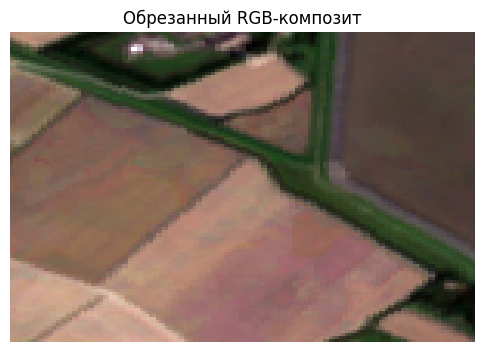

In [54]:
def normalize(band: np.ndarray) -> np.ndarray:
    """
    Normalize raster band to range 0-1.

    :param band: Raster band array

    :return: Normalized band
    """
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm


def visualize_cropped_rgb(cropped_data: np.ndarray) -> None:
    """
    Visualize cropped RGB composite with normalization.

    :param cropped_data: Cropped multispectral raster array

    :return: None
    """
    red_band = cropped_data[0]
    green_band = cropped_data[1]
    blue_band = cropped_data[2]

    red_norm = normalize(red_band)
    green_norm = normalize(green_band)
    blue_norm = normalize(blue_band)

    rgb_image = np.dstack((red_norm, green_norm, blue_norm))

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb_image)
    plt.title("Обрезанный RGB-композит")
    plt.axis("off")
    plt.show()


visualize_cropped_rgb(cropped_raster)


3. Сохраните обрезанное подмножество растра в новый файл с именем `clipped_multispectral.tif`.

In [55]:
def save_cropped_raster(
    source_path: str,
    cropped_data: np.ndarray,
    output_path: str
) -> None:
    """
    Save cropped multispectral raster to new GeoTIFF file.

    :param source_path: Path to original raster file
    :param cropped_data: Cropped raster array
    :param output_path: Path to output GeoTIFF file
    """
    with rasterio.open(source_path) as src:
        profile = src.profile

    profile.update(
        height=cropped_data.shape[1],
        width=cropped_data.shape[2],
        count=cropped_data.shape[0]
    )

    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(cropped_data)

    print("Обрезанный растр сохранён в файл:", output_path)


output_path = "clipped_multispectral.tif"

save_cropped_raster(
    source_path=landsat_path,
    cropped_data=cropped_raster,
    output_path=output_path
)

Обрезанный растр сохранён в файл: clipped_multispectral.tif


In [56]:
with rasterio.open(output_path) as t:
    print(t.width, t.height, t.count)
    print(t.transform)
    print(t.crs)

150 100 4
| 0.00, 0.00, 6.86|
| 0.00,-0.00, 53.42|
| 0.00, 0.00, 1.00|
EPSG:4326


---



### **Задание 4. Вычисление NDWI (калькуляция каналов)**



1. Откройте мультиспектральное изображение и извлеките каналы Green (Зеленый) и Ближний инфракрасный (NIR).


In [70]:
def extract_green_nir_bands(path: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract Green and NIR bands from multispectral raster.

    :param path: Path to multispectral GeoTIFF file

    :return: Tuple containing Green band and NIR band arrays
    """
    with rasterio.open(path) as dataset:
        green_band = dataset.read(2)
        nir_band = dataset.read(4)

    print("Форма зелёного канала:", green_band.shape)
    print("Форма NIR-канала:", nir_band.shape)

    return green_band, nir_band


green_band, nir_band = extract_green_nir_bands(landsat_path)


Форма зелёного канала: (206, 343)
Форма NIR-канала: (206, 343)


2. Вычислите Нормализованный разностный водный индекс ([NDWI](https://en.wikipedia.org/wiki/Normalized_difference_water_index)) по формуле:

    NDWI = (Green - NIR) / (Green + NIR)

In [71]:
def calculate_ndwi(
    green_band: np.ndarray,
    nir_band: np.ndarray
) -> np.ndarray:
    """
    Calculate NDWI from Green and NIR bands.

    :param green_band: Green band array
    :param nir_band: NIR band array

    :return: NDWI array
    """
    green = green_band.astype(float)
    nir = nir_band.astype(float)

    ndwi = np.where(
        (green + nir) == 0,
        0,
        (green - nir) / (green + nir)
    )

    print("NDWI рассчитан")
    print("Минимальное значение NDWI:", ndwi.min())
    print("Максимальное значение NDWI:", ndwi.max())

    return ndwi


ndwi = calculate_ndwi(green_band, nir_band)

NDWI рассчитан
Минимальное значение NDWI: -0.6217616580310881
Максимальное значение NDWI: 0.47722894351545037


3. Визуализируйте результат NDWI с использованием цветовой карты, подходящей для воды (например, cmap='Blues'), чтобы выделить водные объекты.


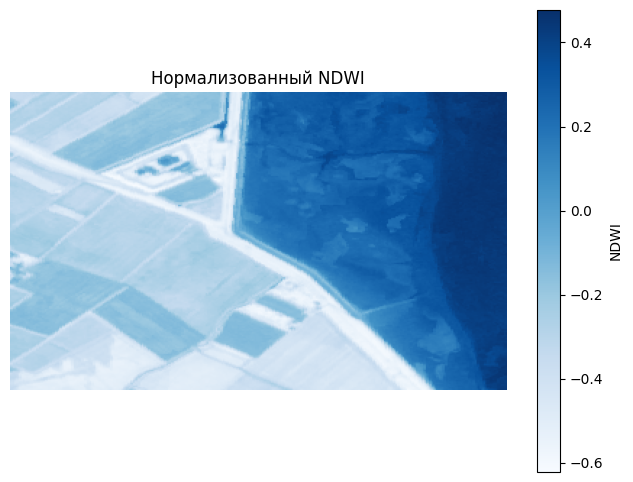

In [72]:
def visualize_ndwi(ndwi: np.ndarray) -> None:
    """
    Visualize NDWI using water-friendly colormap.

    :param ndwi: NDWI array

    :return: None
    """
    plt.figure(figsize=(8, 6))
    plt.imshow(ndwi, cmap="Blues")
    plt.colorbar(label="NDWI")
    plt.title("Нормализованный NDWI")
    plt.axis("off")
    plt.show()


visualize_ndwi(ndwi)




4. Сохраните полученное изображение NDWI как новый растровый файл с именем ndwi.tif.

In [73]:
def save_ndwi_raster(
    source_path: str,
    ndwi: np.ndarray,
    output_path: str
) -> None:
    """
    Save NDWI array to GeoTIFF file.

    :param source_path: Path to source multispectral raster
    :param ndwi: NDWI array
    :param output_path: Path to output NDWI GeoTIFF file
    """
    with rasterio.open(source_path) as src:
        profile = src.profile

    profile.update(
        dtype=rasterio.float32,
        count=1
    )

    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(ndwi.astype(np.float32), 1)

    print("Файл NDWI сохранён:", output_path)


output_ndwi_path = "ndwi.tif"

save_ndwi_raster(
    source_path=landsat_path,
    ndwi=ndwi,
    output_path=output_ndwi_path
)

Файл NDWI сохранён: ndwi.tif


---



### **Задание 5. Перепроецирование растровых данных**



1. Перепроецируйте одноканальный растр ЦМР из его исходной СК в EPSG:4326 (WGS 84) с использованием функции `rasterio.warp.reproject`.


In [74]:
from rasterio.warp import reproject, calculate_default_transform
from rasterio.enums import Resampling


def reproject_dem_to_wgs84(
    source_path: str
) -> tuple[np.ndarray, rasterio.Affine, rasterio.crs.CRS]:
    """
    Reproject DEM raster to EPSG:4326.

    :param source_path: Path to DEM GeoTIFF file

    :return: Tuple containing reprojected array, transform, and CRS
    """
    with rasterio.open(source_path) as src:
        src_crs = src.crs
        dst_crs = "EPSG:4326"

        transform, width, height = calculate_default_transform(
            src_crs,
            dst_crs,
            src.width,
            src.height,
            *src.bounds
        )

        destination = np.empty((height, width), dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=destination,
            src_transform=src.transform,
            src_crs=src_crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear
        )

    print("Исходная СК:", src_crs)
    print("Новая СК:", dst_crs)
    print("Размер перепроецированного растра:", destination.shape)

    return destination, transform, dst_crs

dem_reprojected, dem_transform, dem_crs = reproject_dem_to_wgs84(dem_path)


Исходная СК: EPSG:3857
Новая СК: EPSG:4326
Размер перепроецированного растра: (2642, 4575)


2. Сохраните перепроецированный растр в новый файл GeoTIFF с именем `reprojected_dem.tif`.


In [75]:
import rasterio


def save_reprojected_dem(
    output_path: str,
    dem_array: np.ndarray,
    transform: rasterio.Affine,
    crs: rasterio.crs.CRS
) -> None:
    """
    Save reprojected DEM raster to GeoTIFF file.

    :param output_path: Path to output GeoTIFF file
    :param dem_array: Reprojected DEM array
    :param transform: Affine transform of reprojected raster
    :param crs: CRS of reprojected raster
    """
    height, width = dem_array.shape

    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype=dem_array.dtype,
        crs=crs,
        transform=transform
    ) as dst:
        dst.write(dem_array, 1)

    print("Перепроецированный ЦМР сохранён в файл:", output_path)


output_dem_path = "reprojected_dem.tif"

save_reprojected_dem(
    output_path=output_dem_path,
    dem_array=dem_reprojected,
    transform=dem_transform,
    crs=dem_crs
)


Перепроецированный ЦМР сохранён в файл: reprojected_dem.tif


3. Визуализируйте как исходный, так и перепроецированный наборы данных ЦМР, чтобы сравнить, как перепроецирование влияет на пространственное покрытие и разрешение.

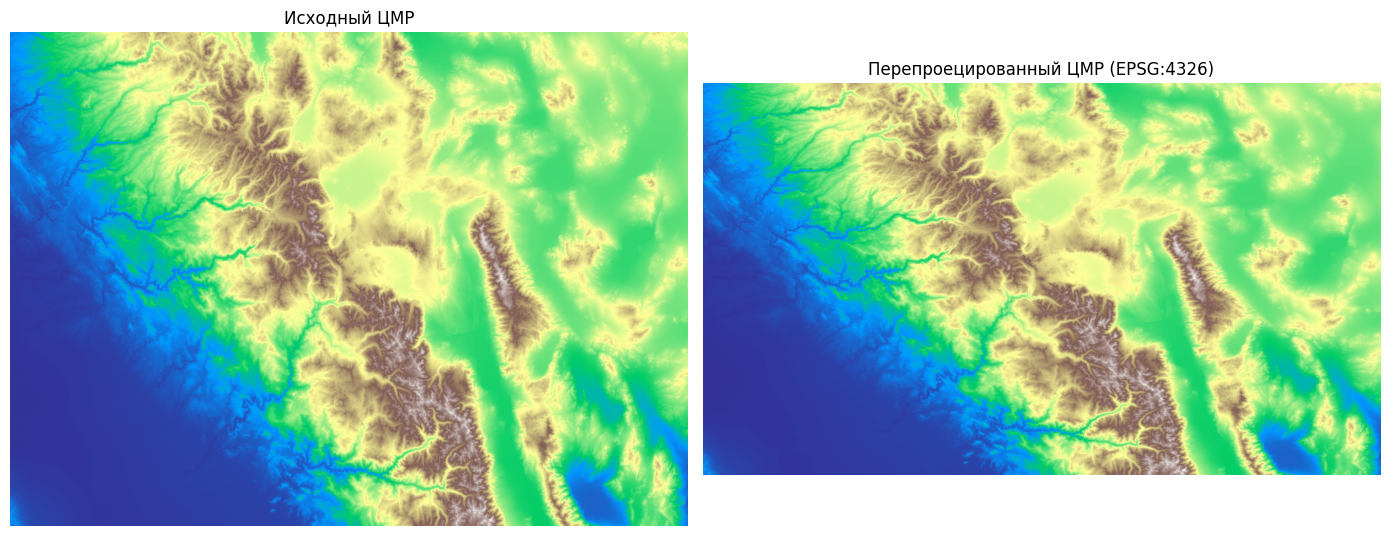

In [79]:
def visualize_dem_comparison(
    original_path: str,
    reprojected_path: str
) -> None:
    """
    Visualize original and reprojected DEM rasters side by side.

    :param original_path: Path to original DEM file
    :param reprojected_path: Path to reprojected DEM file
    """
    with rasterio.open(original_path) as src:
        original_dem = src.read(1)

    with rasterio.open(reprojected_path) as src:
        reprojected_dem = src.read(1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(original_dem, cmap="terrain")
    axes[0].set_title("Исходный ЦМР")
    axes[0].axis("off")

    axes[1].imshow(reprojected_dem, cmap="terrain")
    axes[1].set_title("Перепроецированный ЦМР (EPSG:4326)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


visualize_dem_comparison(
    original_path=dem_path,
    reprojected_path="reprojected_dem.tif"
)


---